In [55]:
import pandas as pd 
features = pd.read_csv('data_A1/X_knn_SVM.csv')
target = pd.read_csv('data_A1/y_knn_SVM.csv')

In [56]:
# Same Focus
target = target["Diagnosis"]

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

### Base Training

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

pca_knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("knn", KNeighborsClassifier())
])

param_grid_pca_knn = {
    "pca__n_components": [2, 5, 10, 15, 20, 30, 40],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"]
}

grid_pca_knn = GridSearchCV(
    pca_knn_pipe,
    param_grid_pca_knn,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_pca_knn.fit(X_train, y_train)

print("Best parameters:", grid_pca_knn.best_params_)
print("Best CV ROC-AUC:", round(grid_pca_knn.best_score_, 3))

Best parameters: {'knn__n_neighbors': 15, 'knn__weights': 'distance', 'pca__n_components': 5}
Best CV ROC-AUC: 0.925


In [59]:
best_pca_knn = grid_pca_knn.best_estimator_

y_pred_pca_knn = best_pca_knn.predict(X_test)
y_score_pca_knn = best_pca_knn.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_pca_knn))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_pca_knn))

auc_pca_knn = roc_auc_score(y_test, y_score_pca_knn)
print(f"Test ROC-AUC: {auc_pca_knn:.3f}")

Confusion Matrix:
 [[43 20]
 [11 81]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.68      0.74        63
         1.0       0.80      0.88      0.84        92

    accuracy                           0.80       155
   macro avg       0.80      0.78      0.79       155
weighted avg       0.80      0.80      0.80       155

Test ROC-AUC: 0.907


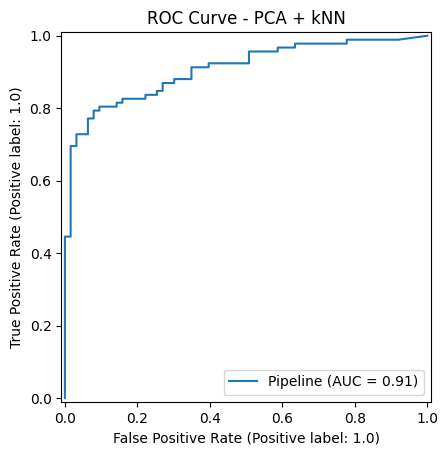

In [60]:
RocCurveDisplay.from_estimator(best_pca_knn, X_test, y_test)
plt.title("ROC Curve - PCA + kNN")
plt.show()

In [61]:
best_pca = best_pca_knn.named_steps["pca"]

print("Number of PCA components:", best_pca.n_components_)
print("Explained variance ratio sum:", round(best_pca.explained_variance_ratio_.sum(), 3))

Number of PCA components: 5
Explained variance ratio sum: 0.314
